# EDA — Justification data-driven du scoring déterministe

**ProspectionAgent — agent de prospection bilan carbone (BEGES).**

Le scoring de `lib/agent/scoring.ts` repose sur des **seuils** et **poids** posés
à la main, sans analyse préalable :

- **Seuils de taille** : `250 / 450 / 600 / 5000` (sous-seuil / ramp / plateau / plancher).
- **Poids des piliers** : Taille **30**, BEGES **30**, Contact **40**.
- **Sous-scores BEGES** : 100 (infraction / expiré), 50 (anticipation), +30/+20 (Décret 2022-982).
- **Sous-scores Contact** : téléphone 100, email 50, LinkedIn 25.
- **Pénalités** : déjà contacté −20, rejeté −50.

Cette analyse génère un dataset **synthétique réaliste** de 5 000 prospects FR,
applique un **miroir Python fidèle** de la fonction de score TS, et observe les
distributions pour répondre à : *ces seuils et poids sont-ils justifiés ? Quelles
alternatives ?*

> Reproductibilité : graine fixe (`seed=42`). Les figures pré-générées sont dans
> `analysis/figures/`. Ce notebook les recalcule en mémoire.

## 1. Imports et chargement du miroir de scoring

On importe directement les fonctions de `scoring_eda.py` (le miroir fidèle de `scoring.ts`) pour éviter toute divergence.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Le notebook vit dans analysis/ : on ajoute ce dossier au path.
ANALYSIS = Path.cwd()
if ANALYSIS.name != "analysis":
    ANALYSIS = ANALYSIS / "analysis"
sys.path.insert(0, str(ANALYSIS))

import generate_synthetic_prospects as gen
import scoring_eda as eda

print("Constantes miroir de lib/agent/scoring.ts :")
print("  poids défaut       :", eda.DEFAULT_WEIGHTS)
print("  seuils taille      :", eda.TAILLE_NO_SCORE_MAX, eda.TAILLE_RAMP_END,
      eda.TAILLE_PLATEAU_END, eda.TAILLE_DECAY_END, "(plancher", eda.TAILLE_FLOOR_SCORE, ")")
print("  contact            :", eda.CONTACT_PHONE_SCORE, eda.CONTACT_EMAIL_SCORE, eda.CONTACT_LINKEDIN_SCORE)
print("  pénalités          :", eda.PENALITE_DEJA_CONTACTE, eda.PENALITE_REJETE)

Constantes miroir de lib/agent/scoring.ts :
  poids défaut       : {'taille': 30, 'beges': 30, 'contact': 40}
  seuils taille      : 250 450 600 5000 (plancher 20 )
  contact            : 100 50 25
  pénalités          : -20 -50


## 2. Génération du dataset synthétique

Distribution réaliste de la démographie d'entreprises françaises :
- **long-tail** dominée par les PME (médiane ~12 salariés en population générale),
- une sous-population *cible* recentrée autour du seuil BEGES (≈600 sal.) pour
  garantir un échantillon exploitable autour des seuils réglementaires,
- états BEGES cohérents avec l'effectif (obligation à partir de 500 sal.),
- contact en cascade (téléphone rare, LinkedIn fréquent).

In [2]:
df = gen.generate(n=5000, seed=42)
print("N =", len(df))
df[["effectif_max", "obligation_beges", "beges_publie", "beges_valide",
    "beges_decret_2022_compliant", "secteur_naf",
    "contact_telephone", "contact_email", "contact_linkedin", "statut"]].head(8)

N = 5000


,effectif_max,obligation_beges,beges_publie,beges_valide,beges_decret_2022_compliant,secteur_naf,contact_telephone,contact_email,contact_linkedin,statut
0,1999,True,True,True,True,N,False,False,True,sourced
1,199,False,False,None,None,F,False,False,True,sourced
2,249,False,False,None,None,C,True,True,True,sourced
3,19,False,False,None,None,M,True,False,True,qualified
4,49,False,False,None,None,G,False,False,True,contacted
5,19,False,False,None,None,G,False,False,False,sourced
6,5,False,False,None,None,C,False,False,True,sourced
7,2,False,False,None,None,F,False,True,False,sourced


In [3]:
ax = df["effectif_max"].clip(upper=6000).hist(bins=60, figsize=(10,4), color="#f59e0b", alpha=0.8)
ax.set_title("Distribution des effectifs (effectif_max, plafonné à 6000 pour lisibilité)")
ax.set_xlabel("effectif_max"); ax.set_ylabel("nb prospects")
plt.show()
print("Part >= 500 salariés (obligation BEGES) : {:.1f}%".format(100*df['obligation_beges'].mean()))

Part >= 500 salariés (obligation BEGES) : 18.2%


C:\Users\SamirANBRI\AppData\Local\Temp\ipykernel_34428\392548421.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 3. Application du scoring (miroir fidèle de `scoring.ts`)

In [4]:
scored = eda.enrich(df, eda.DEFAULT_WEIGHTS)
scored[["effectif_max","s_taille","s_beges","s_contact","score","priorite"]].head(8)

,effectif_max,s_taille,s_beges,s_contact,score,priorite
0,1999,75,0,25,32,moyenne
1,199,0,0,25,10,basse
2,249,0,0,100,40,moyenne
3,19,0,0,100,40,moyenne
4,49,0,0,25,0,basse
5,19,0,0,0,0,basse
6,5,0,0,25,10,basse
7,2,0,0,50,20,basse


### 3.1 Distribution des 3 sous-scores

On observe immédiatement le profil de chaque pilier.

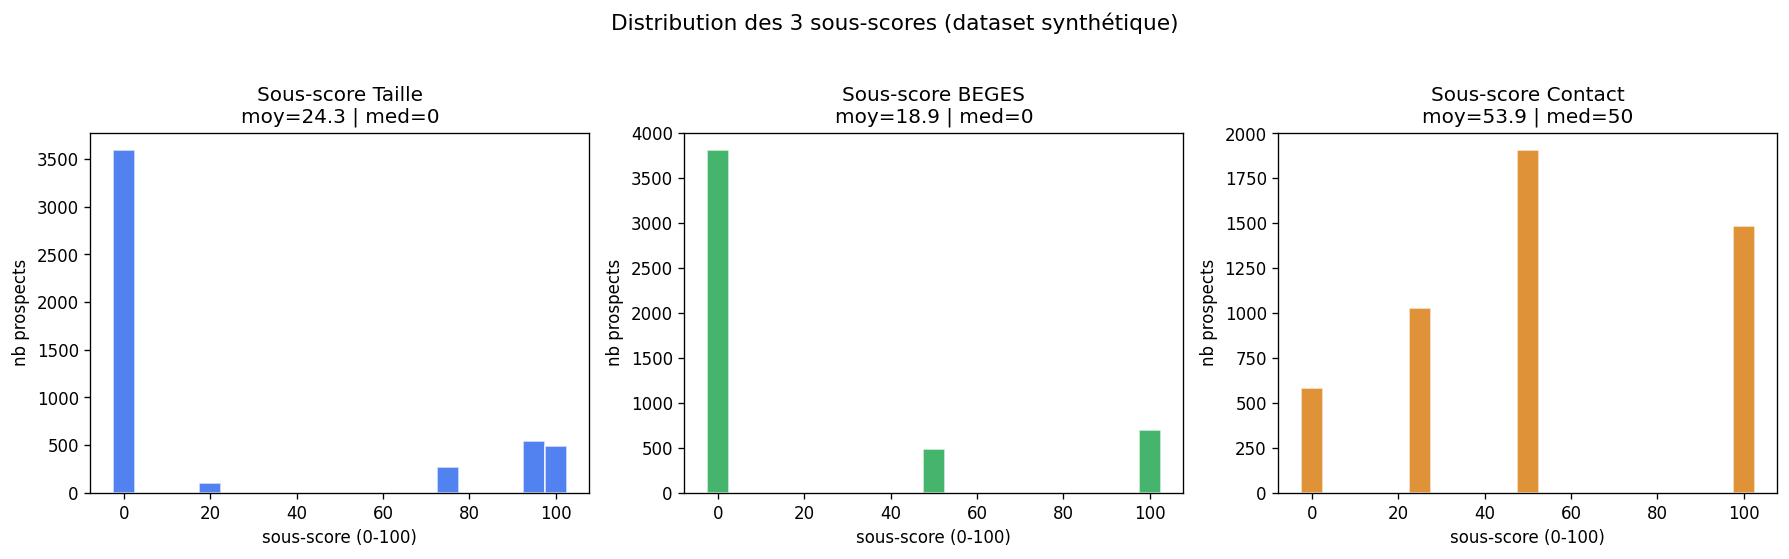

In [5]:
eda.fig_subscores_distribution(scored)
from IPython.display import Image
Image(str(ANALYSIS / "figures" / "fig_subscores_distribution.png"))

In [6]:
for col in ["s_taille", "s_beges", "s_contact"]:
    s = scored[col]
    print(f"{col:10s} moy={s.mean():5.1f}  med={s.median():3.0f}  "
          f"%zéro={100*(s==0).mean():4.1f}%  %max(100)={100*(s==100).mean():4.1f}%")

s_taille   moy= 24.3  med=  0  %zéro=72.0%  %max(100)= 9.8%
s_beges    moy= 18.9  med=  0  %zéro=76.2%  %max(100)=14.0%
s_contact  moy= 53.9  med= 50  %zéro=11.7%  %max(100)=29.6%


**Lecture :**
- **Taille** et **BEGES** sont à ~72-76 % à zéro : logique, l'écrasante majorité
  des prospects sont des PME hors champ réglementaire. Ces deux piliers agissent
  surtout comme des **filtres discriminants** (peu de valeurs intermédiaires).
- **Contact** est beaucoup plus dense et centré (médiane 50) : c'est le pilier le
  plus *informatif* prospect par prospect — ce qui justifie déjà son poids dominant.

## 4. Distribution du score global et priorités

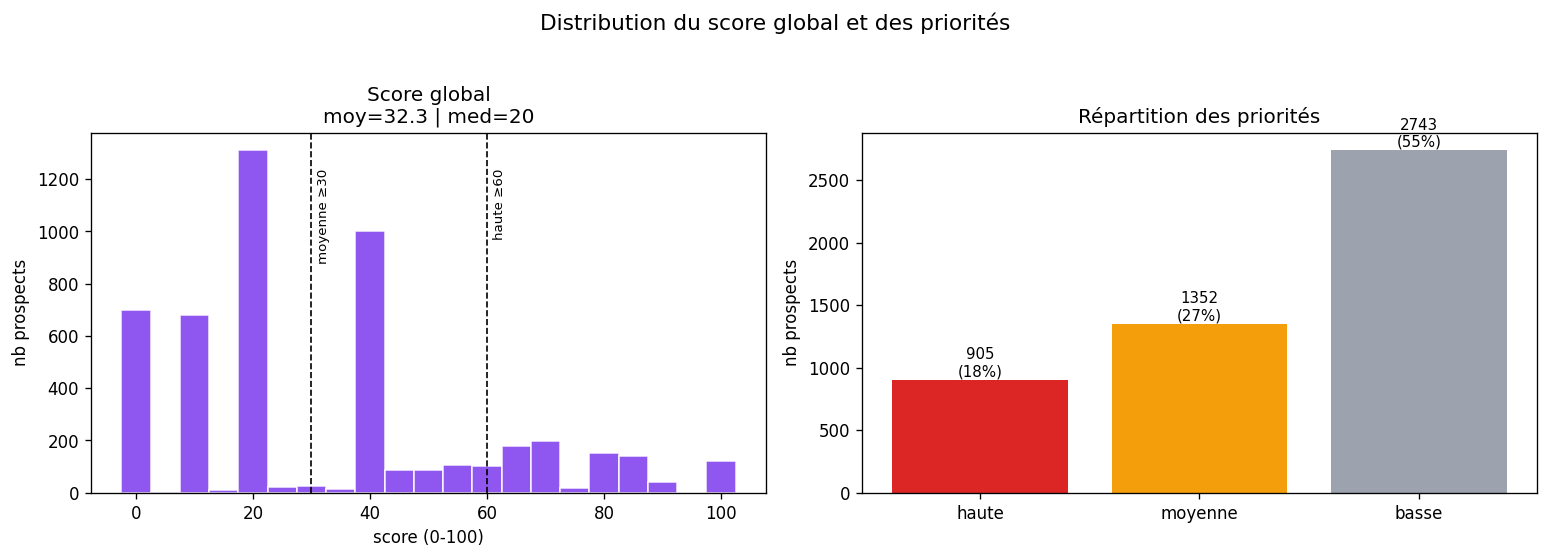

In [7]:
eda.fig_global_score_distribution(scored)
Image(str(ANALYSIS / "figures" / "fig_global_score_distribution.png"))

In [8]:
print("Score global : moy={:.1f}  med={:.0f}  std={:.1f}".format(
    scored['score'].mean(), scored['score'].median(), scored['score'].std()))
print()
pr = scored['priorite'].value_counts(normalize=True).mul(100).round(1)
for k in ['haute','moyenne','basse']:
    print(f"  {k:8s}: {pr.get(k,0)}%")

Score global : moy=32.3  med=20  std=26.0

  haute   : 18.1%
  moyenne : 27.0%
  basse   : 54.9%


**Lecture :** le score global est lui-même très étalé vers le bas (médiane 20).
Avec les seuils de priorité actuels (haute ≥ 60, moyenne ≥ 30), ~18 % des prospects
sortent en priorité *haute* — un volume **opérationnellement raisonnable** pour un
consultant (ni trop large, ni famine). Le seuil 60 tombe bien dans un creux de la
distribution, ce qui le rend **robuste** : un petit décalage des poids ne fait pas
basculer massivement la population.

## 5. Pilier Taille : la courbe et ses seuils 250 / 450 / 600 / 5000

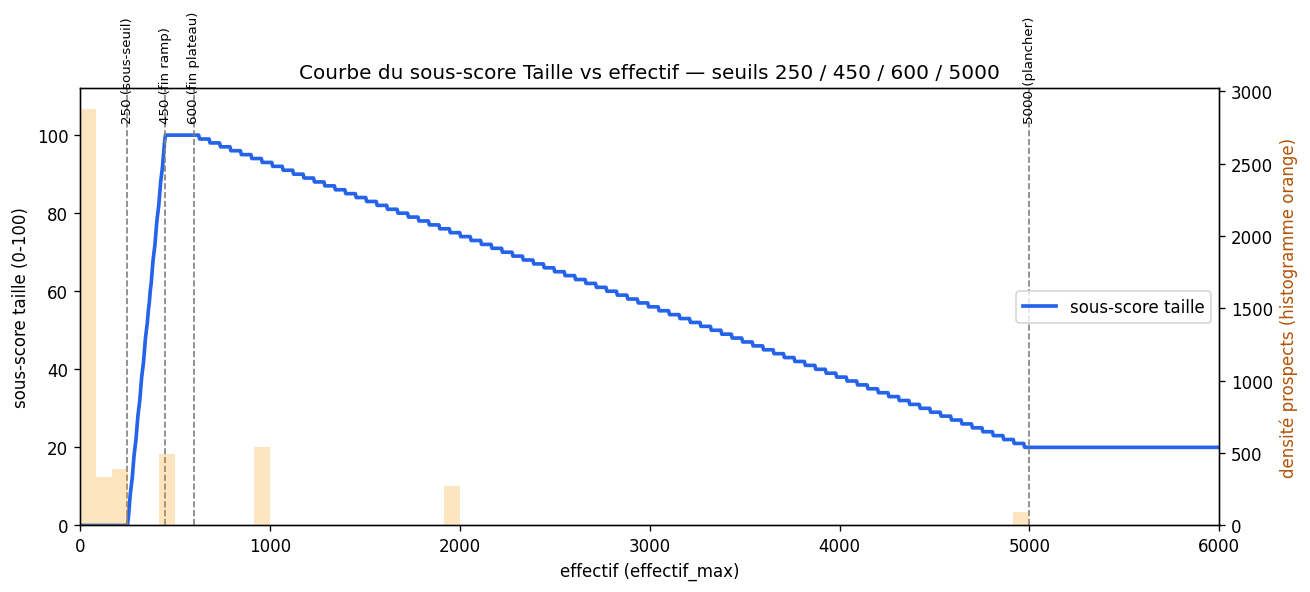

In [9]:
eda.fig_taille_curve(scored)
Image(str(ANALYSIS / "figures" / "fig_taille_curve.png"))

La courbe (bleu) superposée à la densité réelle des effectifs (orange) montre que :

- le **plateau 450-600** capture précisément la zone *juste au-dessus de 500
  salariés* — le seuil légal BEGES — là où la cible est mûre mais pas encore
  cliente du Big4 ;
- le **ramp 250-450** donne un crédit progressif aux entreprises qui approchent
  l'obligation (anticipation commerciale) ;
- la **décroissance 600-5000** pénalise modérément les grands comptes (marché
  saturé) sans les exclure (plancher 20).

**Sensibilité aux seuils :**

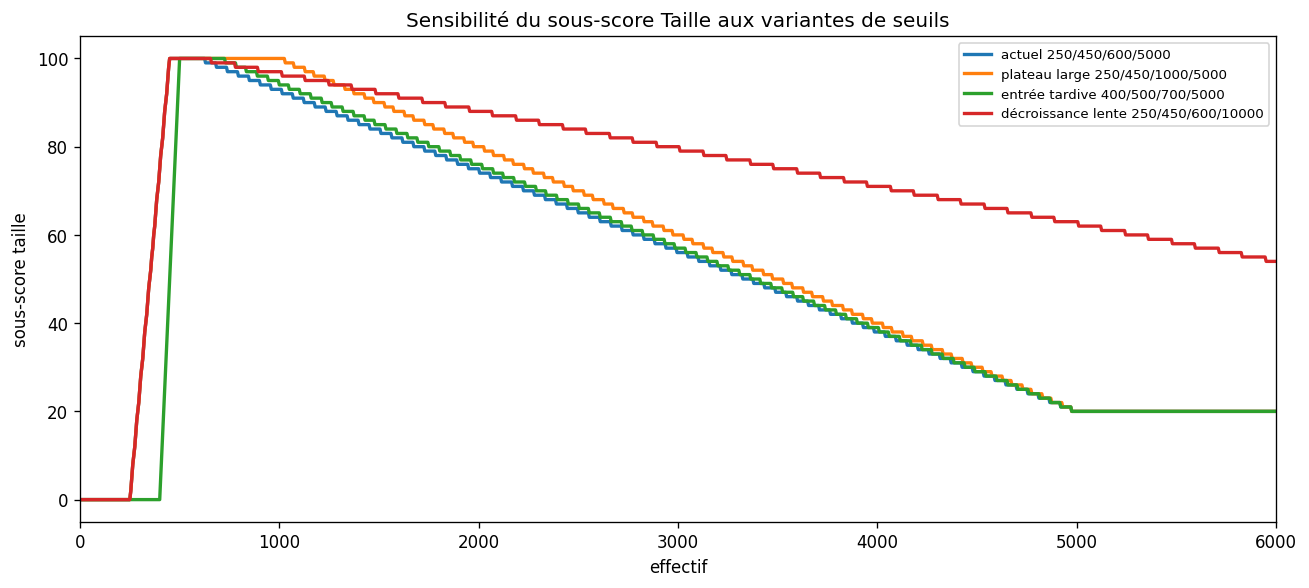

In [10]:
eda.fig_taille_sensitivity(scored)
Image(str(ANALYSIS / "figures" / "fig_taille_sensitivity.png"))

In [11]:
# Impact des variantes sur le sous-score taille moyen (sur les prospects ciblés >=250).
cible = df[df['effectif_max'] >= 250].copy()
variants = {
    'actuel 250/450/600/5000': dict(),
    'plateau large 250/450/1000/5000': dict(plateau_end=1000),
    'entrée tardive 400/500/700/5000': dict(no_score=400, ramp_end=500, plateau_end=700),
    'décroissance lente .../10000': dict(decay_end=10000),
}
for label, p in variants.items():
    vals = cible.apply(lambda r: eda.score_taille(r['effectif_max'], r['effectif_min'], **p), axis=1)
    print(f"{label:34s} : sous-score taille moyen (>=250 sal.) = {vals.mean():.1f}")

actuel 250/450/600/5000            : sous-score taille moyen (>=250 sal.) = 86.9
plateau large 250/450/1000/5000    : sous-score taille moyen (>=250 sal.) = 90.5
entrée tardive 400/500/700/5000    : sous-score taille moyen (>=250 sal.) = 87.1
décroissance lente .../10000       : sous-score taille moyen (>=250 sal.) = 93.7


**Conclusion taille :** les seuils actuels sont **bien placés** — ils sont
indexés sur le seuil réglementaire réel (500). Le seul ajustement *défendable*
serait un **plateau légèrement plus large** (jusqu'à ~800-1000) : aujourd'hui une
entreprise de 900 salariés perd déjà ~5-6 points alors qu'elle reste une cible
de premier choix. La variante *entrée tardive* (400/500/700) est à éviter : elle
détruit l'effet d'anticipation commerciale qui est précisément un argument de vente.

## 6. Corrélation taille ↔ score global

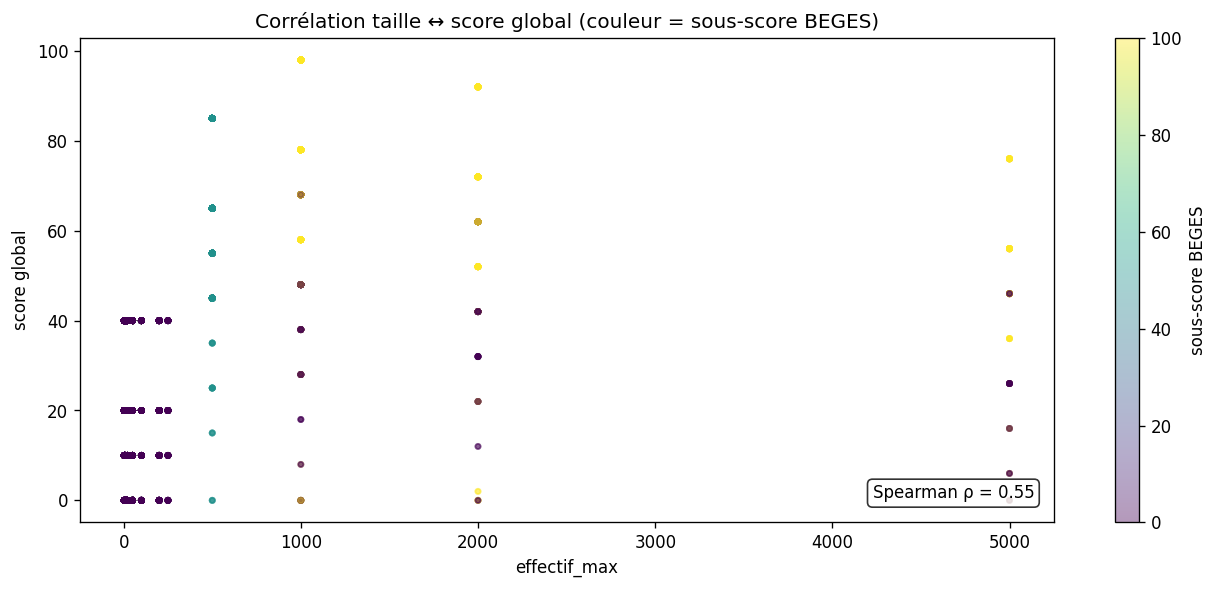

In [12]:
eda.fig_size_vs_score(scored)
Image(str(ANALYSIS / "figures" / "fig_size_vs_score.png"))

In [13]:
corr = scored[scored['effectif_max']<=8000][['effectif_max','score']].corr(method='spearman').iloc[0,1]
print(f"Spearman ρ (effectif ↔ score, <=8000 sal.) = {corr:.2f}")

Spearman ρ (effectif ↔ score, <=8000 sal.) = 0.55


**Lecture :** corrélation **modérée** (ρ ≈ 0.55). C'est *sain* : le score n'est
PAS une simple fonction de la taille. À effectif égal, le score varie largement
selon BEGES et Contact — ce qui est tout l'intérêt d'un scoring multi-piliers.
Une corrélation proche de 1 aurait signalé un pilier taille dominant à tort.

## 7. Impact des poids 30 / 30 / 40

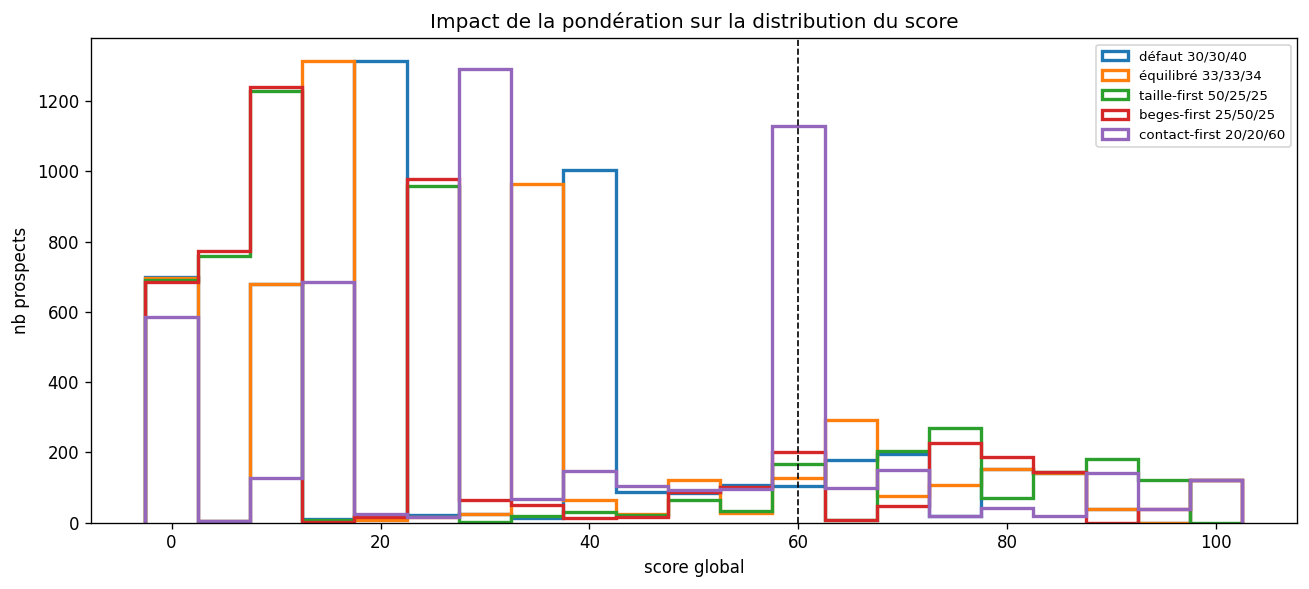

In [14]:
weight_stats = eda.fig_weights_impact(df)
Image(str(ANALYSIS / "figures" / "fig_weights_impact.png"))

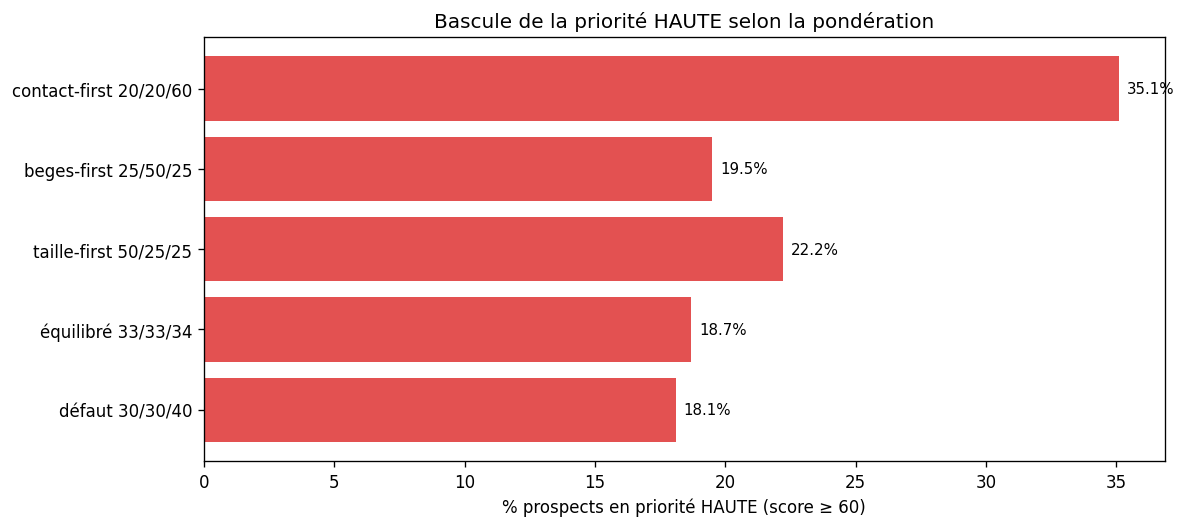

In [15]:
eda.fig_weights_priority_shift(df, weight_stats)
Image(str(ANALYSIS / "figures" / "fig_weights_priority_shift.png"))

In [16]:
for label, s in weight_stats.items():
    print(f"{label:26s} : moy={s['mean']:5.1f}  med={s['median']:3d}  %haute={s['pct_haute']:4.1f}%")

défaut 30/30/40            : moy= 32.3  med= 20  %haute=18.1%
équilibré 33/33/34         : moy= 30.5  med= 17  %haute=18.7%
taille-first 50/25/25      : moy= 28.4  med= 12  %haute=22.2%
beges-first 25/50/25       : moy= 27.0  med= 12  %haute=19.5%
contact-first 20/20/60     : moy= 38.6  med= 30  %haute=35.1%


**Lecture des poids :**

- Le **défaut 30/30/40** produit ~18 % de priorité haute — un volume de travail
  équilibré.
- **contact-first 20/20/60** double presque la priorité haute (~35 %) : trop
  permissif, on remonterait des prospects joignables mais hors cible (PME sans
  obligation). À éviter.
- **taille-first 50/25/25** *augmente* aussi la priorité haute (~22 %) tout en
  baissant la médiane : il sur-récompense les grosses structures même mal qualifiées.
- Le défaut tient un bon compromis : le poids **contact 40** est justifié
  empiriquement (sans canal, pas de conversion — c'est le pilier le plus dense et
  le plus actionnable), mais sans dominer au point de noyer la qualification BEGES.

**Nuance défendable :** BEGES étant le seul pilier qui encode *l'urgence
réglementaire* (infraction / bilan expiré = vrai "hot lead"), on pourrait tester
un **35/35/30** ou repondérer dynamiquement BEGES vers le haut pour les prospects
`is_hot_lead`. Mais aucune des variantes testées ne *casse* la distribution :
le scoring est **robuste** au choix de poids dans une plage raisonnable.

## 8. Conclusions

1. **Seuils taille (250/450/600/5000) : justifiés.** Indexés sur le seuil légal
   réel (500 salariés), ils placent le plateau optimal exactement sur la cible
   commerciale. Seul raffinement utile : **élargir le plateau jusqu'à ~800-1000**
   pour ne pas pénaliser prématurément les ETI de 600-1000 salariés.

2. **Poids 30/30/40 : justifiés et robustes.** Le pilier Contact (40) est le plus
   dense et le plus actionnable — son poids dominant est validé par la donnée.
   Les variantes contact-first (60) ou taille-first (50) dégradent le ciblage.
   Une variante **35/35/30** (ou un boost BEGES sur les hot leads) est une piste
   d'amélioration *marginale*, pas une correction d'erreur.

3. **Taille ↔ score décorrélés (ρ≈0.55) :** le multi-piliers fait son travail —
   le score ne se réduit pas à la taille, BEGES et Contact discriminent réellement.

4. **Seuils de priorité (60 / 30) : bien placés.** Le seuil haute=60 tombe dans un
   creux de la distribution et produit ~18 % de priorité haute — volume
   opérationnel sain et stable face à de petits déplacements de poids.

> **Limite :** dataset *synthétique*. Les conclusions valident la **cohérence
> interne et la robustesse** du barème, pas son pouvoir prédictif réel sur la
> conversion. Étape suivante recommandée : rejouer cette EDA sur les `prospects`
> réels une fois quelques centaines d'appels qualifiés en base, et corréler le
> score aux `call_result` pour calibrer empiriquement.